<a href="https://colab.research.google.com/github/kangtayie/Machine-Learning_class/blob/main/wine_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Dataset EDA 실습

이번 실습에서는 다음 내용을 확인합니다.
1. 데이터 불러오기
2. 데이터 구조 확인
3. 결측치와 중복 데이터 확인
4. 레이블 종류와 개수 확인
5. 기술통계량 확인
6. 품종별 평균과 표준편차 확인
7. 변수별 분포 확인
8. 품종별 분포 비교
9. Box Plot과 Violin Plot
10. Pair Plot
11. 상관관계 분석
12. 산점도를 이용한 변수 관계 확인
13. IQR 기반 이상치 탐지
14. 품종별 평균 비교
15. 변동계수 확인
16. 변수별 품종 분리도 확인
17. EDA 결과 해석

In [1]:
# 구글 드라이브 마운트

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. 필요한 라이브러리 불러오기

`pandas`는 데이터 처리, `numpy`는 수치 계산, `matplotlib`과 `seaborn`은 시각화를 위해 사용합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 변수별 품종 분리도(ANOVA F값)를 계산하는 함수
from sklearn.feature_selection import f_classif

sns.set_theme(style="whitegrid")

## 2. 데이터 불러오기

`wine.csv` 파일을 읽어 `df`라는 DataFrame에 저장합니다.

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")

df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


## 3. 데이터 구조 확인

- `shape`: 행과 열의 개수
- `head()`: 처음 5개 행
- `columns`: 변수 이름
- `dtypes`: 각 변수의 자료형
- `info()`: 데이터 전체 구조 요약

`Wine` 열은 숫자(1, 2, 3)로 저장되어 있지만 크기를 뜻하는 값이 아니라 **품종을 구분하는 레이블**입니다.

In [6]:
print("데이터 크기:", df.shape)

print("\n처음 5개 데이터")
display(df.head())

print("\n변수 이름")
print(df.columns.tolist())

print("\n자료형")
print(df.dtypes)

print("\n데이터 정보")
df.info()

데이터 크기: (178, 14)

처음 5개 데이터


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



변수 이름
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

자료형
Wine                      int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   As

## 4. 결측치와 중복 데이터 확인

결측치가 많으면 분석 결과에 영향을 줄 수 있으므로 반드시 확인해야 합니다.

중복 데이터가 많으면 특정 관측값이 분석 결과에 과도한 영향을 줄 수 있습니다.

In [7]:
# isnull(): 값이 비어 있으면 True, sum(): True 개수를 열별로 합산
print("변수별 결측치 개수")
print(df.isnull().sum())

# duplicated(): 앞에 나온 행과 완전히 같은 행이면 True, sum(): 그 개수
print("\n중복 행 개수")
print(df.duplicated().sum())

변수별 결측치 개수
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

중복 행 개수
0


## 5. 분석 변수 지정

와인 데이터에는 13개의 연속형 화학 성분 변수와 하나의 품종 레이블이 있습니다.

- `Alcohol`: 알코올
- `Malic.acid`: 말산(사과산)
- `Ash`: 회분
- `Acl`: 회분의 알칼리도
- `Mg`: 마그네슘
- `Phenols`: 총 페놀
- `Flavanoids`: 플라바노이드
- `Nonflavanoid.phenols`: 비플라바노이드 페놀
- `Proanth`: 프로안토시아닌
- `Color.int`: 색의 강도
- `Hue`: 색조
- `OD`: 희석 와인의 OD280/OD315 값
- `Proline`: 프롤린
- `Wine`: 와인 품종 (1, 2, 3)

In [8]:
target_col = 'Wine'

numeric_cols = [col for col in df.columns if col != target_col]

# 잘 골라졌는지 개수와 이름 확인
print("측정 변수 개수:", len(numeric_cols))
print(numeric_cols)

측정 변수 개수: 13
['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']


## 6. 레이블 종류와 개수 확인

분류 문제에서는 각 레이블이 무엇인지, 그리고 각 레이블의 데이터 개수가 얼마나 되는지 확인하는 것이 중요합니다.

레이블별 데이터 수가 크게 차이 난다면 클래스 불균형 문제가 있을 수 있습니다.

In [9]:
print("레이블 종류")
print(sorted(df[target_col].unique().tolist()))

print("\n레이블별 개수")
print(df[target_col].value_counts().sort_index())

print("\n레이블별 비율(%)")
print((df[target_col].value_counts(normalize=True).sort_index() * 100).round(1))

레이블 종류
[1, 2, 3]

레이블별 개수
Wine
1    59
2    71
3    48
Name: count, dtype: int64

레이블별 비율(%)
Wine
1    33.1
2    39.9
3    27.0
Name: proportion, dtype: float64


### 레이블 개수 시각화

`countplot`은 각 범주에 몇 개의 데이터가 존재하는지 막대그래프로 보여줍니다. 막대 위에 실제 데이터 개수도 함께 표시합니다.

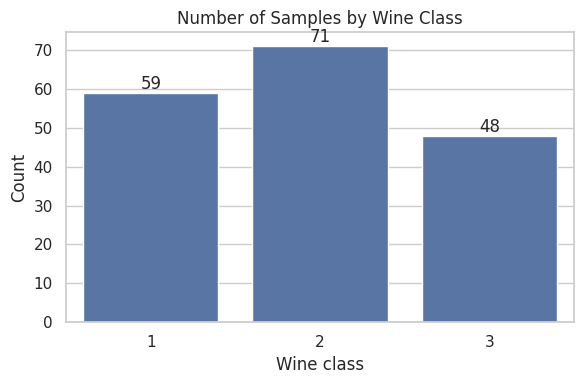

In [10]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,        # 사용할 데이터
    x=target_col    # x축에 놓을 열
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by Wine Class")
plt.xlabel("Wine class")
plt.ylabel("Count")

plt.tight_layout()   # 그래프 요소가 겹치지 않게 여백 자동 조정
plt.show()           # 그래프 출력

## 7. 기술통계량 확인

`describe()`는 수치형 변수의 기본적인 통계량을 보여줍니다.

와인 데이터는 변수마다 값의 크기가 크게 달라서 평균과 표준편차의 규모를 함께 살펴봐야 합니다.

In [11]:
display(df[numeric_cols].describe().round(3).T)

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83
Malic.acid,178.0,2.336,1.117,0.74,1.602,1.865,3.082,5.80
Ash,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23
Acl,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00
Mg,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00
Phenols,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88
Flavanoids,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08
Nonflavanoid.phenols,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66
Proanth,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58
Color.int,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00


## 8. 품종별 평균과 표준편차 확인

`groupby()`를 이용하면 데이터를 품종별로 나누어 평균과 표준편차를 계산할 수 있습니다.

품종별 평균 차이가 큰 변수는 품종 구별에 유용할 가능성이 있습니다.

In [12]:
print("품종별 평균")
display(
    df.groupby(target_col)[numeric_cols]
      .mean()
      .round(3)
      .T
)

# 같은 방식으로 표준편차 계산
print("품종별 표준편차")
display(
    df.groupby(target_col)[numeric_cols]
      .std()
      .round(3)
      .T
)

품종별 평균


Wine,1,2,3
Alcohol,13.745,12.279,13.154
Malic.acid,2.011,1.933,3.334
Ash,2.456,2.245,2.437
Acl,17.037,20.238,21.417
Mg,106.339,94.549,99.312
Phenols,2.840,2.259,1.679
Flavanoids,2.982,2.081,0.781
Nonflavanoid.phenols,0.290,0.364,0.448
Proanth,1.899,1.630,1.154
Color.int,5.528,3.087,7.396


품종별 표준편차


Wine,1,2,3
Alcohol,0.462,0.538,0.530
Malic.acid,0.689,1.016,1.088
Ash,0.227,0.315,0.185
Acl,2.546,3.350,2.258
Mg,10.499,16.753,10.890
Phenols,0.339,0.545,0.357
Flavanoids,0.397,0.706,0.294
Nonflavanoid.phenols,0.070,0.124,0.124
Proanth,0.412,0.602,0.409
Color.int,1.239,0.925,2.311


## 9. 각 변수의 전체 분포 확인

히스토그램은 값이 어느 구간에 많이 존재하는지 보여줍니다.

`kde=True`를 사용하면 분포를 부드러운 밀도 곡선으로 함께 표시할 수 있습니다.

변수가 13개이므로 그래프를 하나씩 그리지 않고 한 화면에 격자(subplot)로 모아서 그립니다.

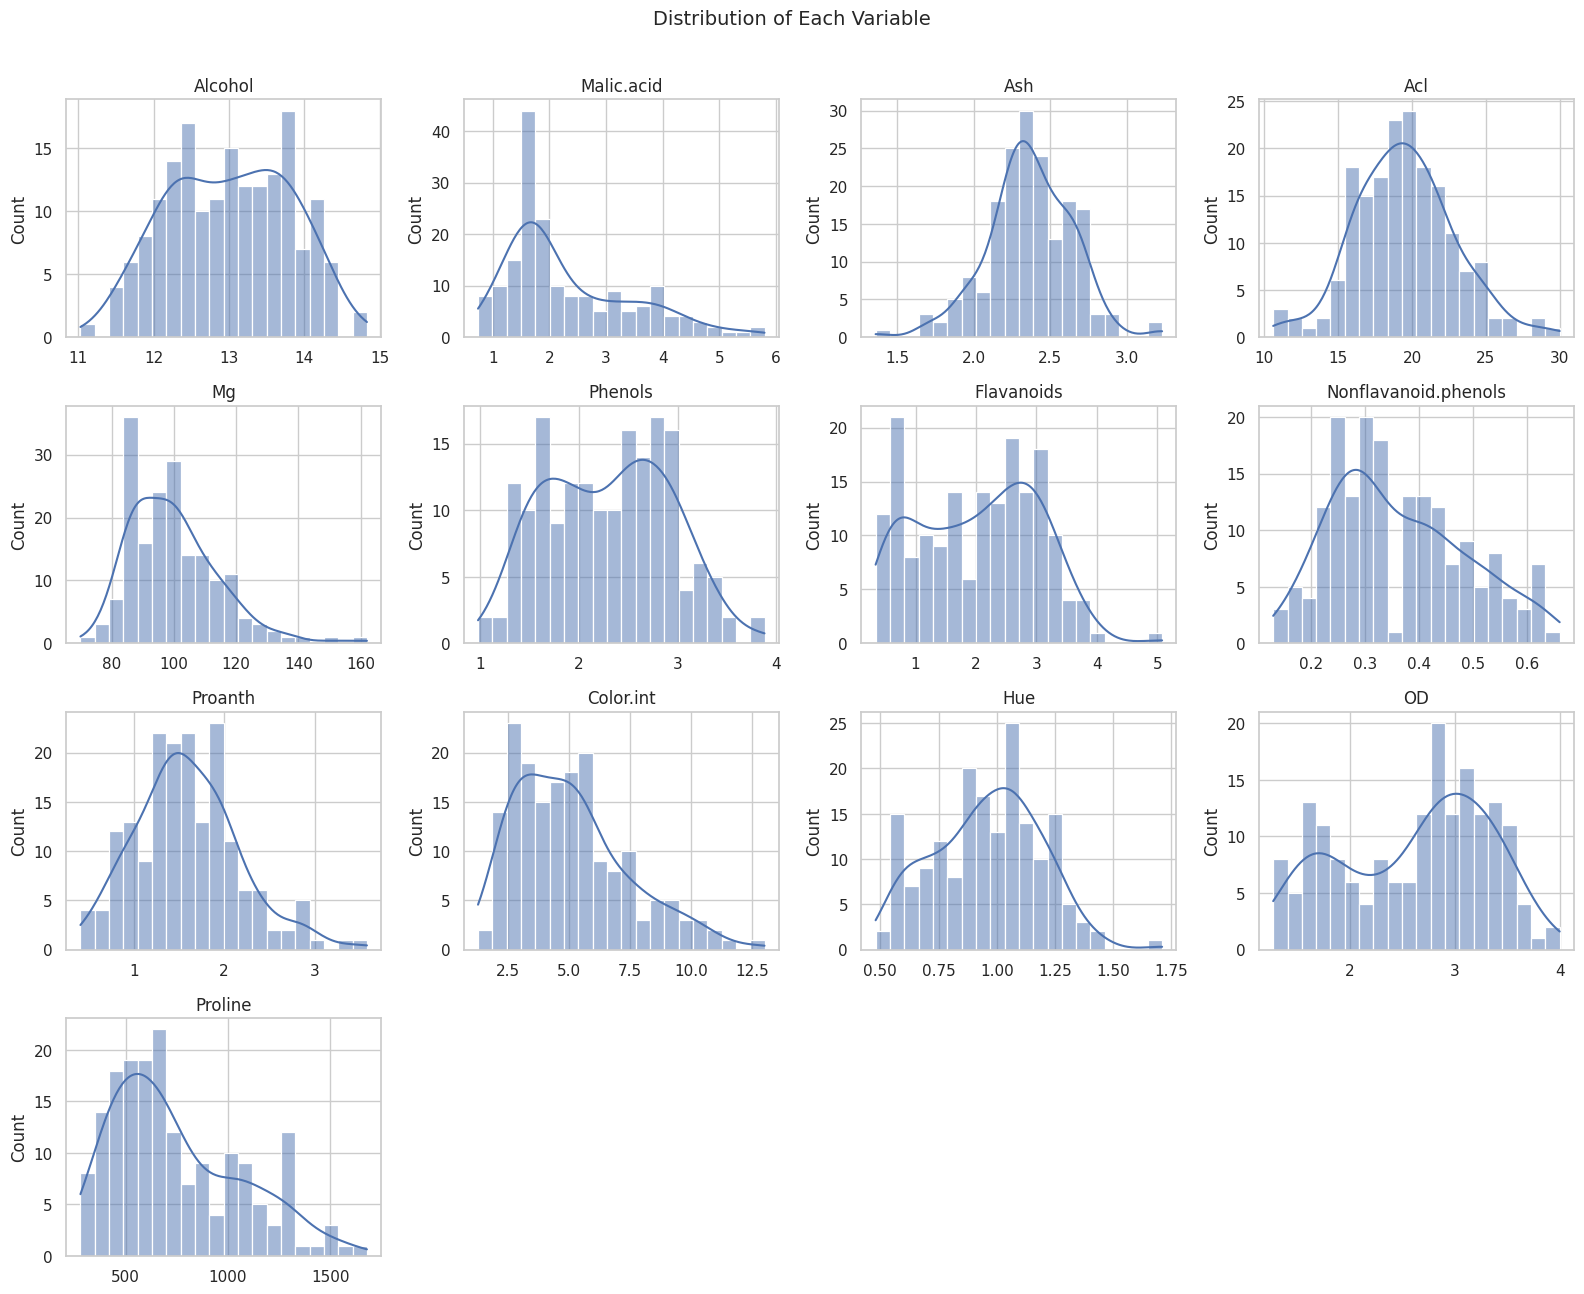

In [13]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.suptitle("Distribution of Each Variable", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 10. 품종별 변수 분포 비교

같은 변수에서 품종 1, 2, 3의 분포를 동시에 비교합니다.

품종별 분포가 서로 많이 떨어져 있다면 해당 변수가 품종을 구별하는 데 유용할 가능성이 높습니다.

클래스 개수가 다르므로 `stat="density"`, `common_norm=False`로 각 품종을 같은 기준으로 비교합니다.

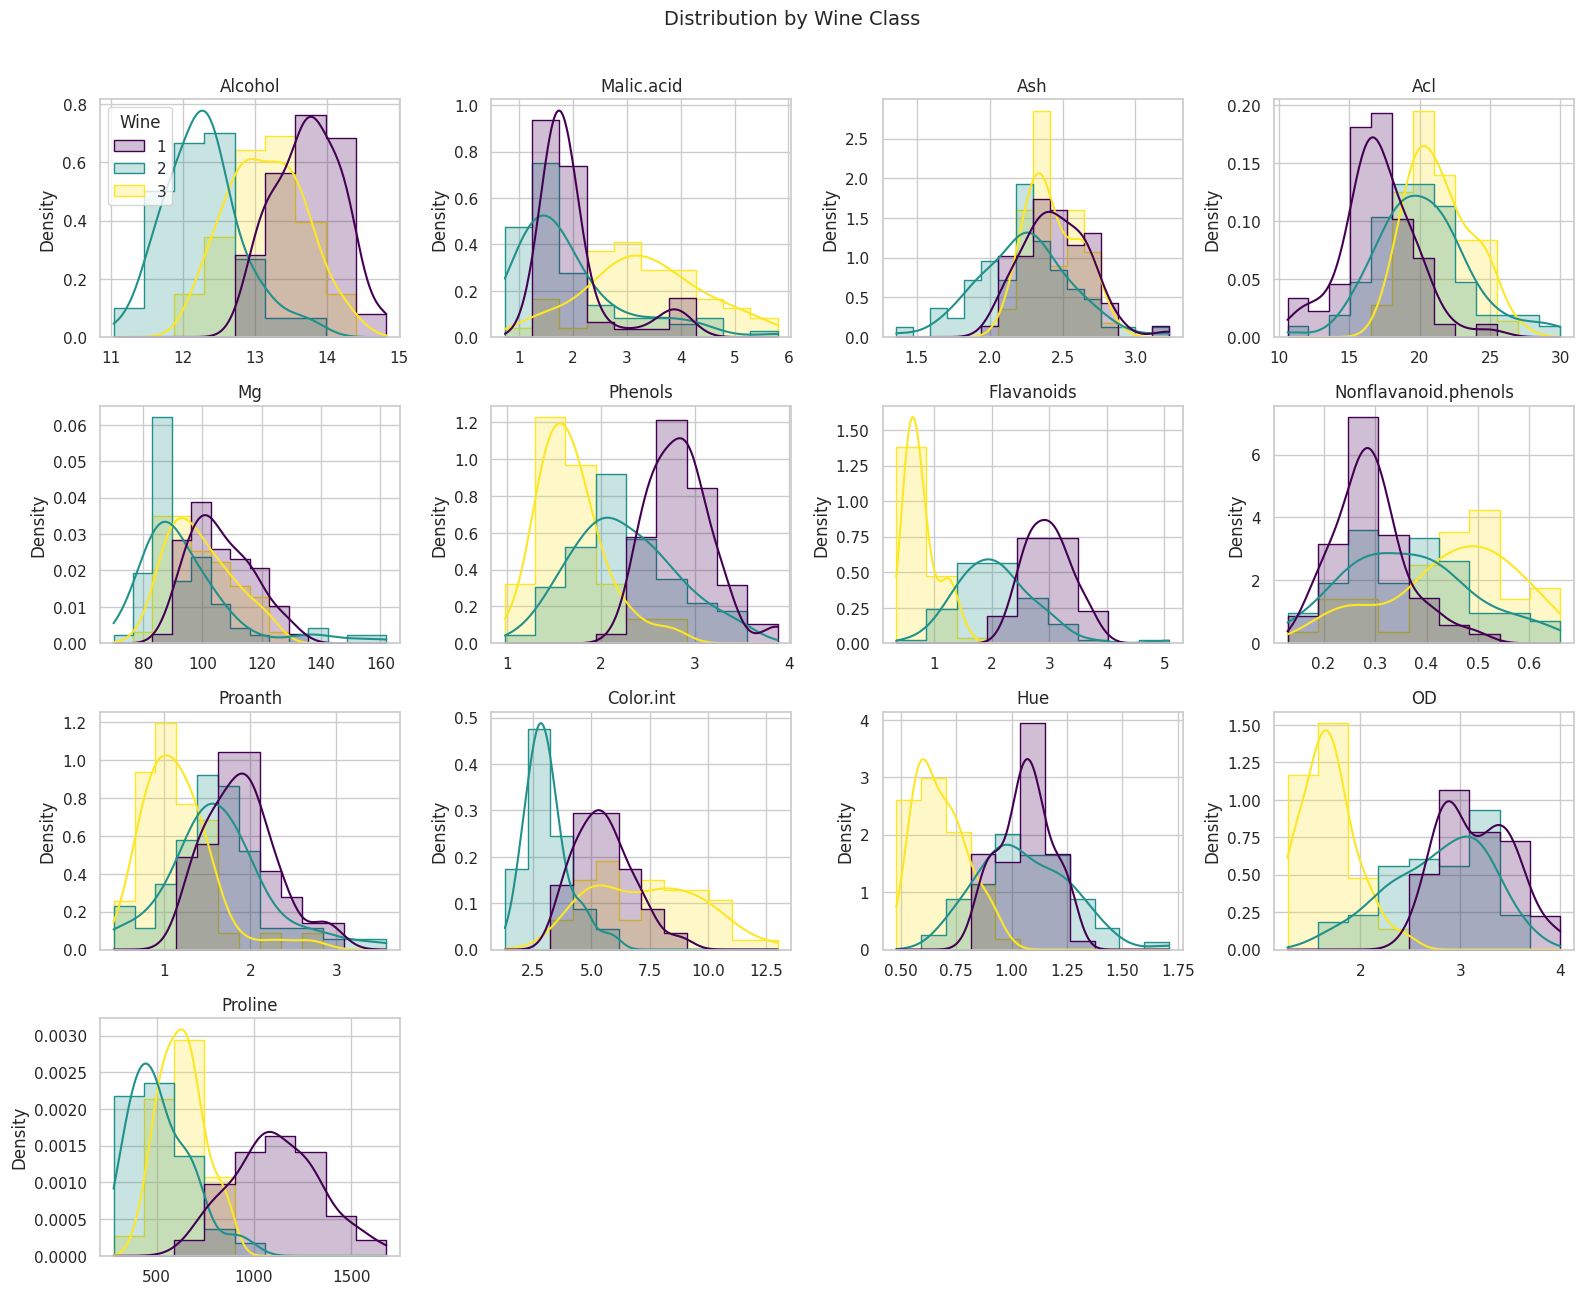

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,          # Wine 값(1,2,3)에 따라 색을 다르게
        kde=True,                # 밀도 곡선도 함께
        element="step",          # 막대를 채우지 않고 윤곽선 위주로 그려 겹침이 잘 보이게
        stat="density",          # 개수 대신 '밀도'로 표시 -> 품종별 샘플 수가 달라도 공정하게 비교
        common_norm=False,       # 품종마다 따로 정규화 (각 품종의 면적이 1)
        palette="viridis",       # 색상 팔레트
        legend=(col == numeric_cols[0]),   # 범례는 첫 번째 그래프에만 표시
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.suptitle("Distribution by Wine Class", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 11. Box Plot

Box Plot은 중앙값, 사분위수, 데이터 범위, 이상치 등을 한 번에 확인할 수 있습니다.

품종별 중앙값과 분포 범위를 비교하면 각 변수에서 품종 차이가 얼마나 큰지 확인할 수 있습니다.

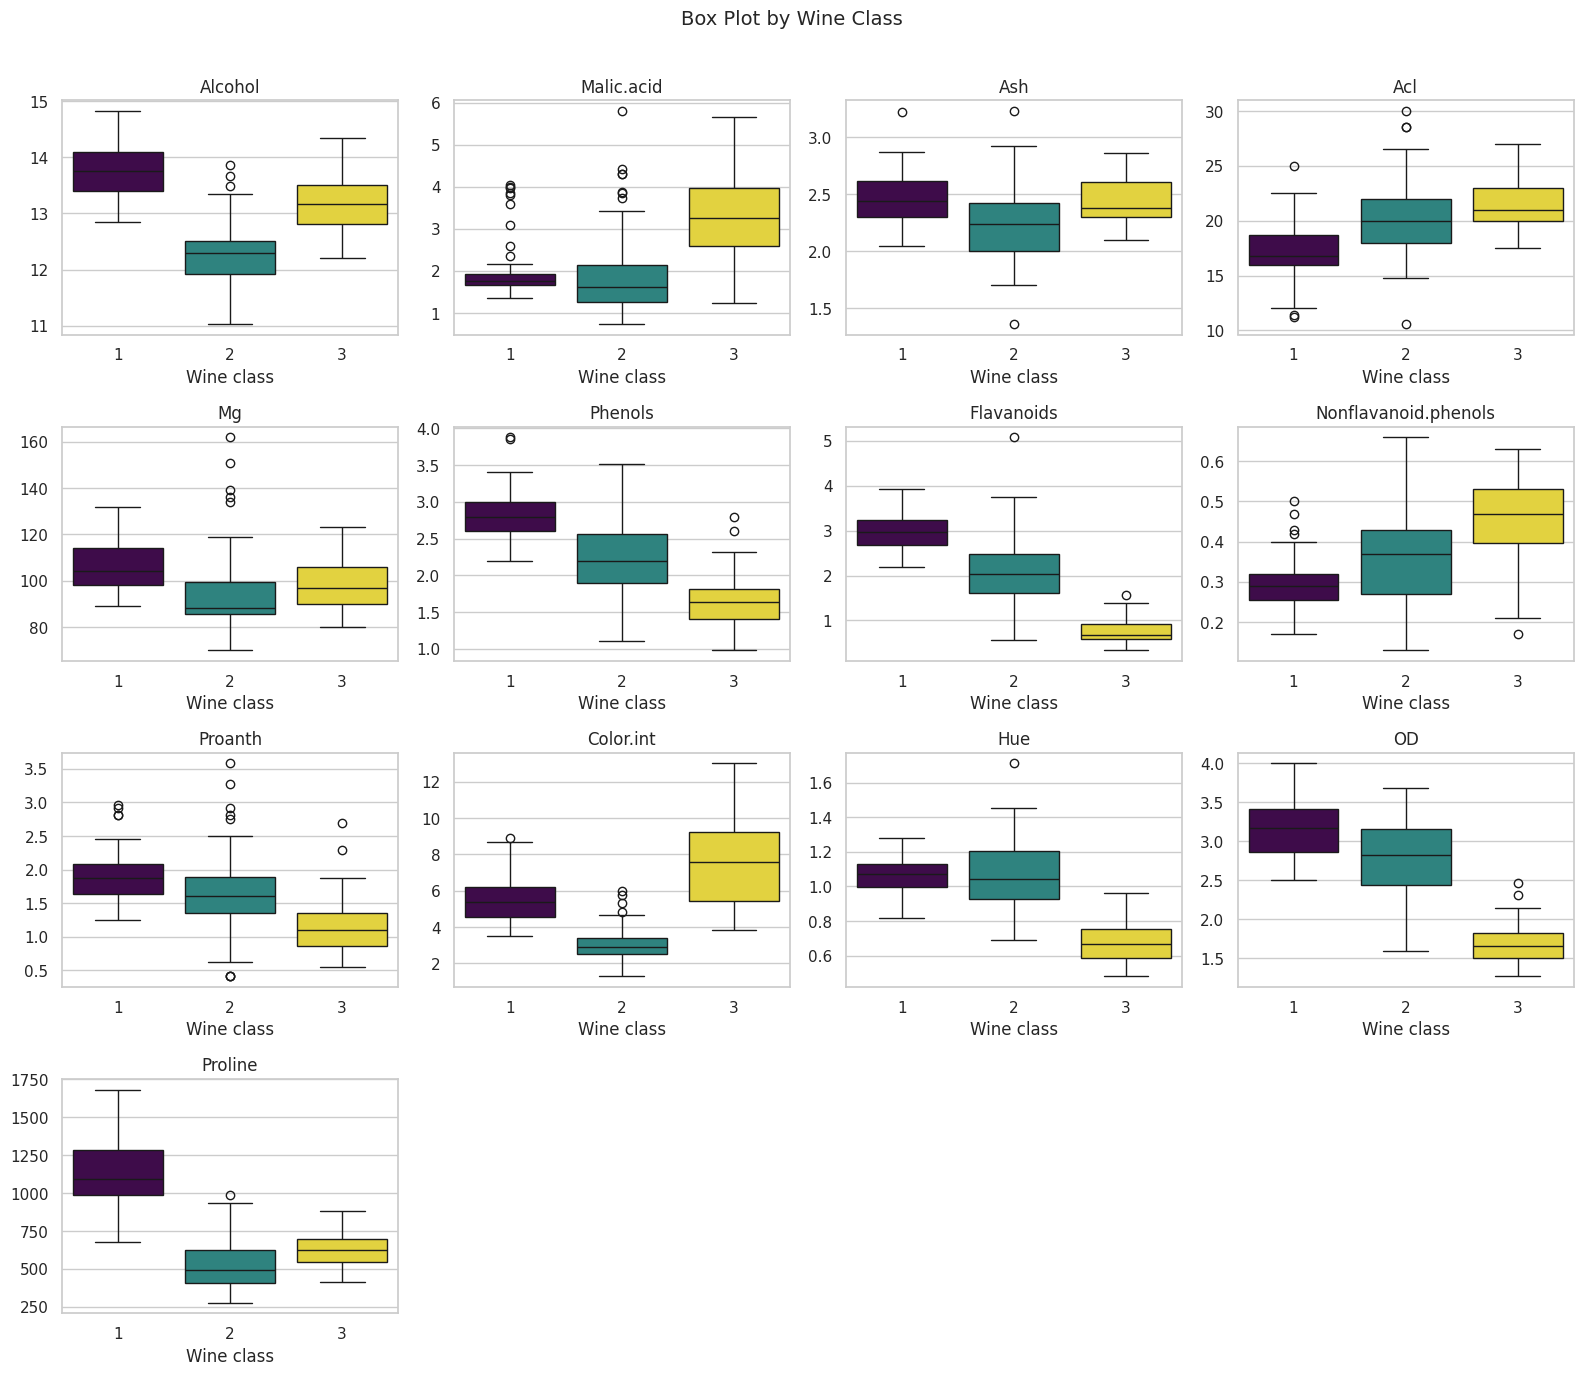

In [15]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        data=df,
        x=target_col,        # x축: 품종
        y=col,               # y축: 측정값
        hue=target_col,      # 품종별 색상
        palette="viridis",
        legend=False,        # x축에 이미 품종이 표시되므로 범례는 생략
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("Wine class")
    ax.set_ylabel("")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.suptitle("Box Plot by Wine Class", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 12. Violin Plot

Violin Plot은 Box Plot과 유사하지만 데이터의 밀도까지 함께 보여줍니다.

그래프가 넓은 부분은 해당 값 근처에 데이터가 많이 존재한다는 의미입니다.

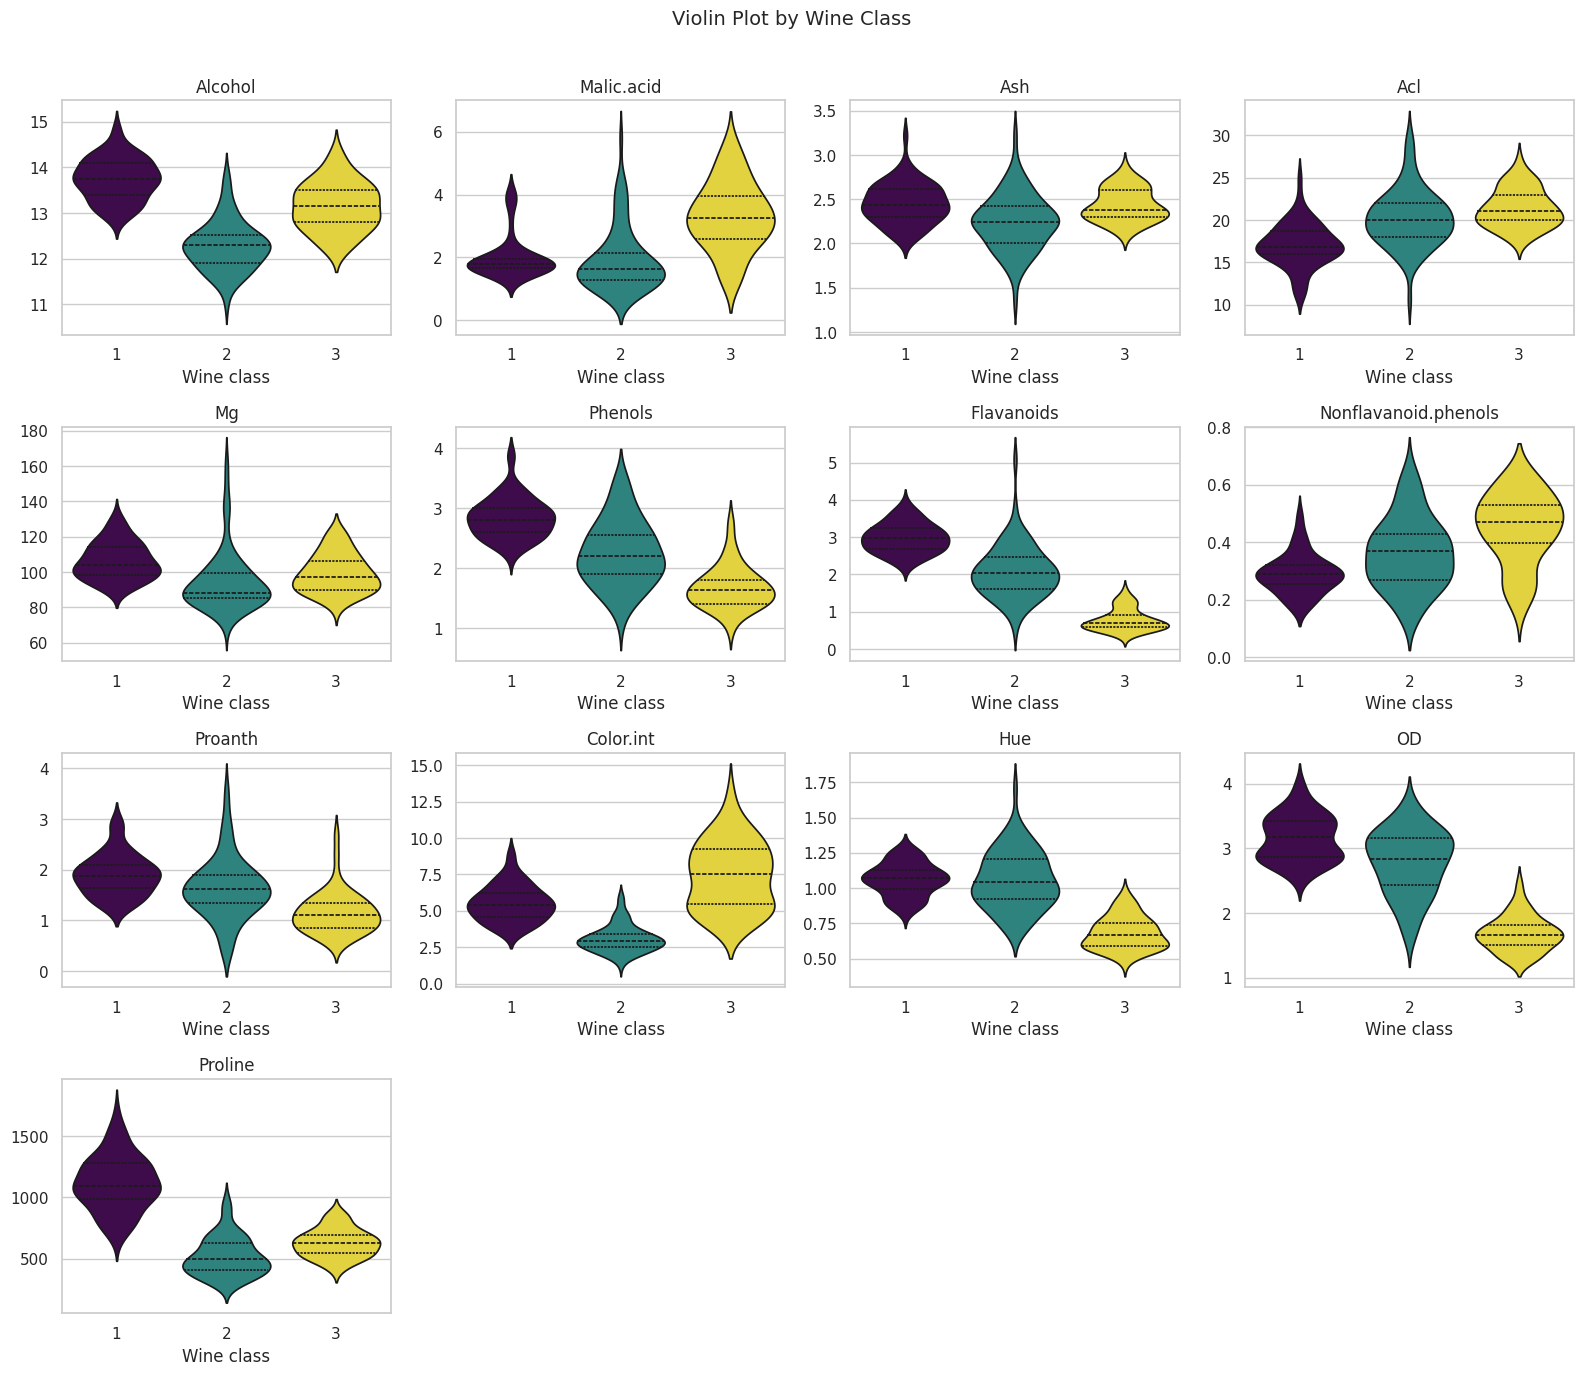

In [16]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.violinplot(
        data=df,
        x=target_col,
        y=col,
        hue=target_col,
        palette="viridis",
        legend=False,
        inner="quartile",
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("Wine class")
    ax.set_ylabel("")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.suptitle("Violin Plot by Wine Class", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 13. Pair Plot

Pair Plot은 모든 변수 조합의 관계를 한 번에 보여주는 EDA 그래프입니다.

변수가 13개이면 13 x 13 = 169개의 그래프가 되어 읽기 어렵기 때문에, 앞에서 품종별 차이가 뚜렷했던 변수 5개만 골라서 그립니다.

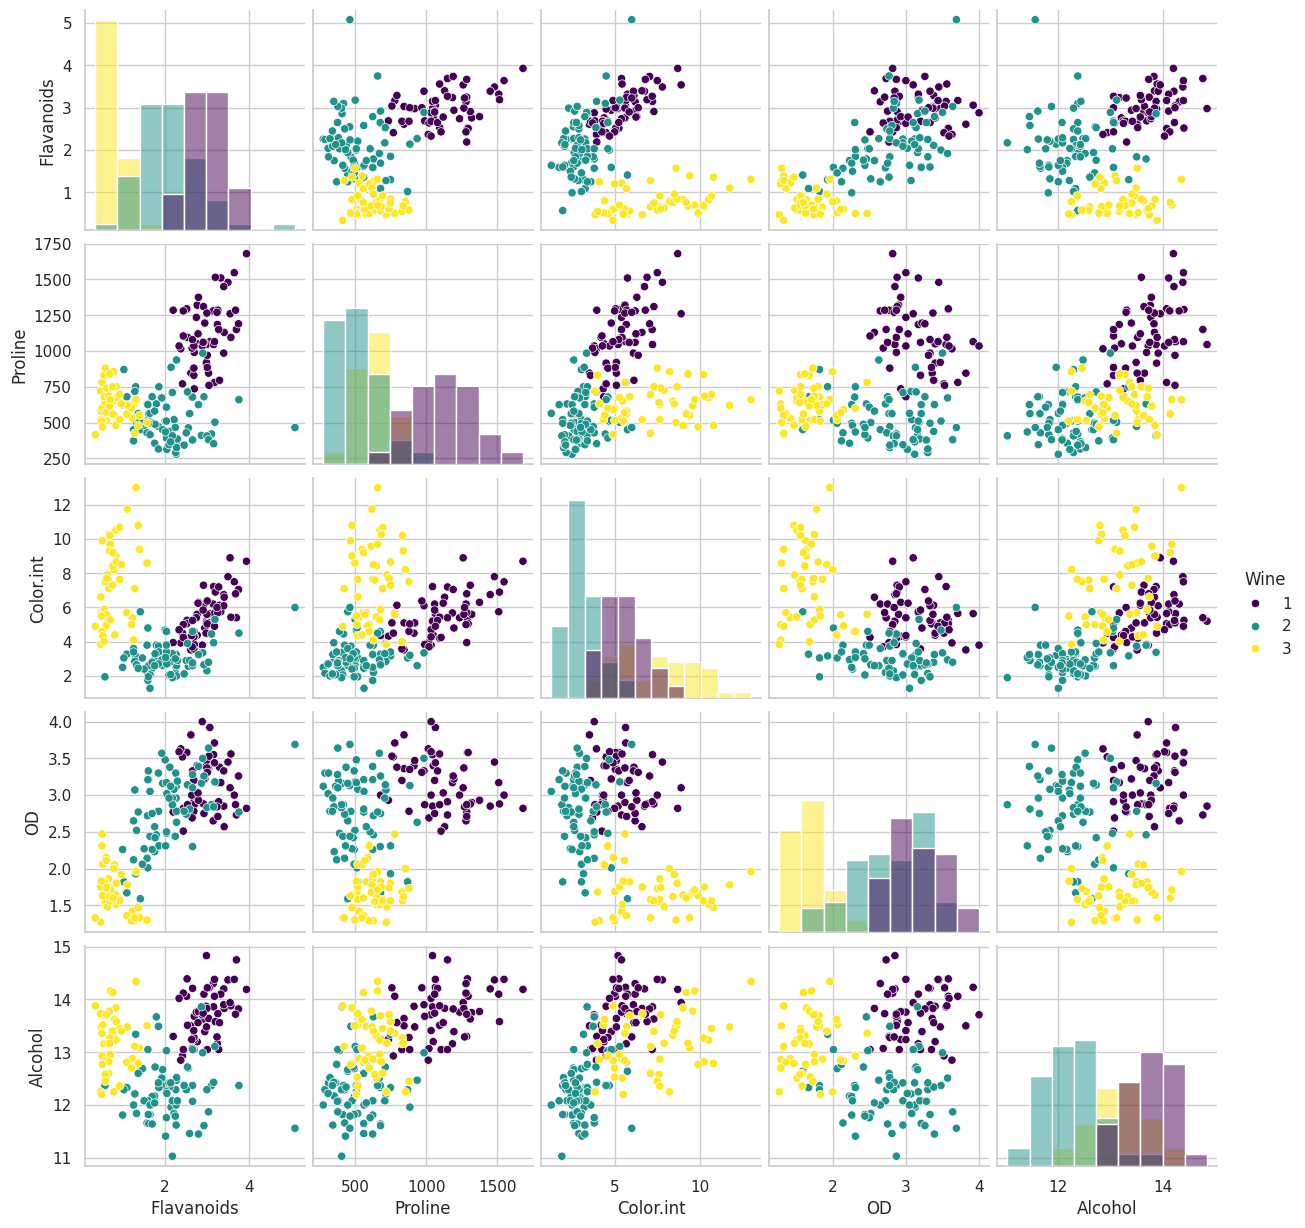

In [17]:
pair_cols = ['Flavanoids', 'Proline', 'Color.int', 'OD', 'Alcohol']

sns.pairplot(
    df,
    vars=pair_cols,
    hue=target_col,
    diag_kind="hist",
    palette="viridis"
)

plt.show()

## 14. 변수 간 상관관계 분석

상관계수는 두 변수 사이의 선형적인 관계를 나타냅니다.

- 1에 가까움: 강한 양의 상관관계
- 0에 가까움: 선형적인 관계가 약함
- -1에 가까움: 강한 음의 상관관계

상관관계가 높다고 해서 반드시 인과관계가 있다는 의미는 아닙니다.

In [18]:
# corr(): 변수들 사이의 상관계수 행렬 계산 (-1 ~ 1)
# 값이 1에 가까우면 함께 커지는 관계, -1에 가까우면 한쪽이 커질 때 다른 쪽은 작아지는 관계
corr = df[numeric_cols].corr()

display(corr.round(2))

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.00,0.09,0.21,-0.31,0.27,0.29,0.24,-0.16,0.14,0.55,-0.07,0.07,0.64
Malic.acid,0.09,1.00,0.16,0.29,-0.05,-0.34,-0.41,0.29,-0.22,0.25,-0.56,-0.37,-0.19
Ash,0.21,0.16,1.00,0.44,0.29,0.13,0.12,0.19,0.01,0.26,-0.07,0.00,0.22
Acl,-0.31,0.29,0.44,1.00,-0.08,-0.32,-0.35,0.36,-0.20,0.02,-0.27,-0.28,-0.44
Mg,0.27,-0.05,0.29,-0.08,1.00,0.21,0.20,-0.26,0.24,0.20,0.06,0.07,0.39
Phenols,0.29,-0.34,0.13,-0.32,0.21,1.00,0.86,-0.45,0.61,-0.06,0.43,0.70,0.50
Flavanoids,0.24,-0.41,0.12,-0.35,0.20,0.86,1.00,-0.54,0.65,-0.17,0.54,0.79,0.49
Nonflavanoid.phenols,-0.16,0.29,0.19,0.36,-0.26,-0.45,-0.54,1.00,-0.37,0.14,-0.26,-0.50,-0.31
Proanth,0.14,-0.22,0.01,-0.20,0.24,0.61,0.65,-0.37,1.00,-0.03,0.30,0.52,0.33
Color.int,0.55,0.25,0.26,0.02,0.20,-0.06,-0.17,0.14,-0.03,1.00,-0.52,-0.43,0.32


### 상관관계 Heatmap

Heatmap을 이용하면 변수 사이의 상관관계를 색과 숫자로 쉽게 비교할 수 있습니다.

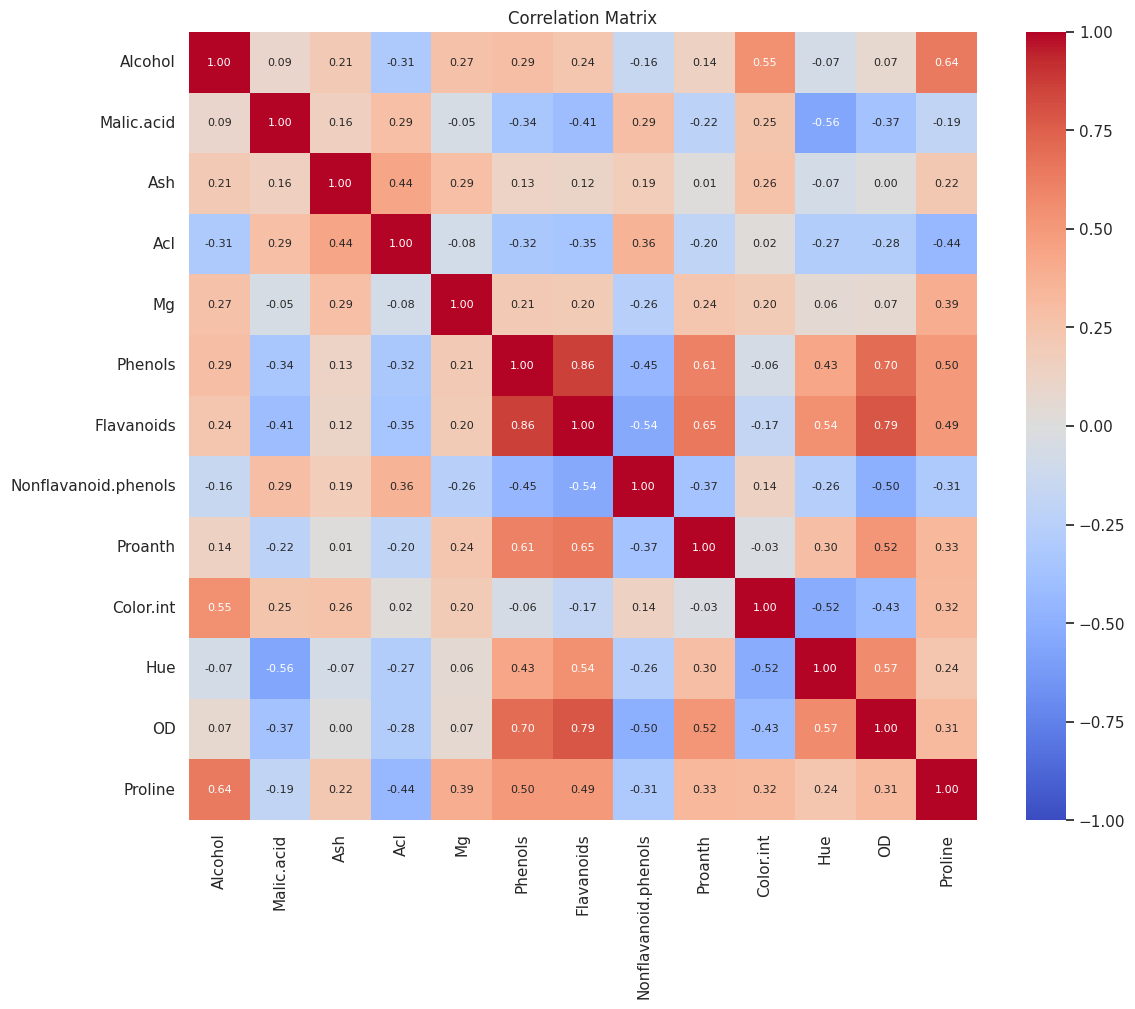

In [19]:
plt.figure(figsize=(12, 10))

# heatmap: 상관계수 행렬을 색으로 표현
sns.heatmap(
    corr,
    annot=True,                  # 칸 안에 숫자 표시
    fmt=".2f",                   # 소수 둘째 자리까지
    annot_kws={"size": 8},       # 숫자 글자 크기 (변수가 많아서 작게)
    cmap="coolwarm",             # 빨강 = 양의 상관, 파랑 = 음의 상관
    vmin=-1,                     # 색 범위를 -1 ~ 1로 고정해서 공정하게 비교
    vmax=1,
    square=True                  # 칸을 정사각형으로
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### 상관관계가 큰 변수 쌍 정리


Heatmap에서 눈으로 찾기 어려우므로, 서로 다른 변수 쌍의 상관계수를 절댓값이 큰 순서로 정리합니다.

In [20]:
# 상관행렬은 대칭이라 같은 쌍이 두 번 나온다 (A-B, B-A) 그리고 대각선은 항상 1이다.
# np.triu(k=1): 대각선 바로 위쪽 삼각형만 True인 마스크를 만들어 중복을 제거한다
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

corr_pairs = (
    corr.where(mask)          # 마스크가 True인 칸만 남기고 나머지는 NaN
        .stack()              # 행렬 -> (변수1, 변수2, 값) 형태의 긴 목록으로 변환 (NaN은 제외)
        .rename("corr")       # 값 열의 이름을 corr로 지정
        .reset_index()        # 인덱스를 열로 꺼내서 표로 만든다
        .rename(columns={"level_0": "var1", "level_1": "var2"})   # 열 이름을 보기 쉽게 변경
)

# 양의 상관이든 음의 상관이든 '얼마나 강한가'를 보려고 절댓값 열을 추가
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()

# 절댓값이 내림차순으로 정렬해서 상위 8개만 출력
print("상관관계 절댓값 상위 8개")
display(corr_pairs.sort_values("abs_corr", ascending=False).head(8).round(3))

상관관계 절댓값 상위 8개


,var1,var2,corr,abs_corr
50,Phenols,Flavanoids,0.865,0.865
61,Flavanoids,OD,0.787,0.787
55,Phenols,OD,0.700,0.700
58,Flavanoids,Proanth,0.653,0.653
11,Alcohol,Proline,0.644,0.644
52,Phenols,Proanth,0.612,0.612
75,Hue,OD,0.565,0.565
20,Malic.acid,Hue,-0.561,0.561


## 15. 품종 구분이 잘 되는 변수 조합의 산점도

산점도는 두 연속형 변수 사이의 관계를 확인할 때 사용합니다.

각 점은 하나의 와인 샘플이며, 색은 품종을 나타냅니다.

`Flavanoids`와 `Color.int`는 세 품종이 서로 다른 위치에 모이는 조합입니다.

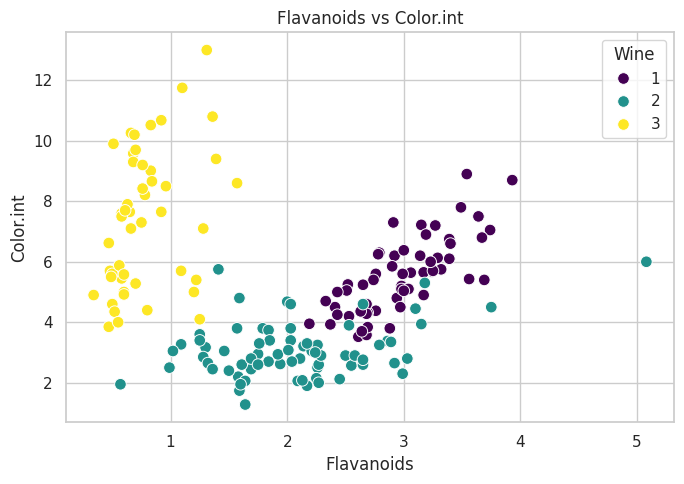

In [21]:
plt.figure(figsize=(7, 5))

# scatterplot: 점 하나가 와인 샘플 하나. x, y 위치가 두 변수의 값이다
sns.scatterplot(
    data=df,
    x='Flavanoids',
    y='Color.int',
    hue=target_col,        # 품종별로 색 구분
    palette="viridis",
    s=70                   # 점 크기
)

plt.title("Flavanoids vs Color.int")
plt.xlabel("Flavanoids")
plt.ylabel("Color.int")

plt.tight_layout()
plt.show()

## 16. 품종 구분이 어려운 변수 조합의 산점도

비교를 위해 `Alcohol`과 `Malic.acid`의 관계도 확인합니다.

이 조합에서는 품종별 데이터가 상대적으로 더 많이 겹치는 것을 볼 수 있습니다.

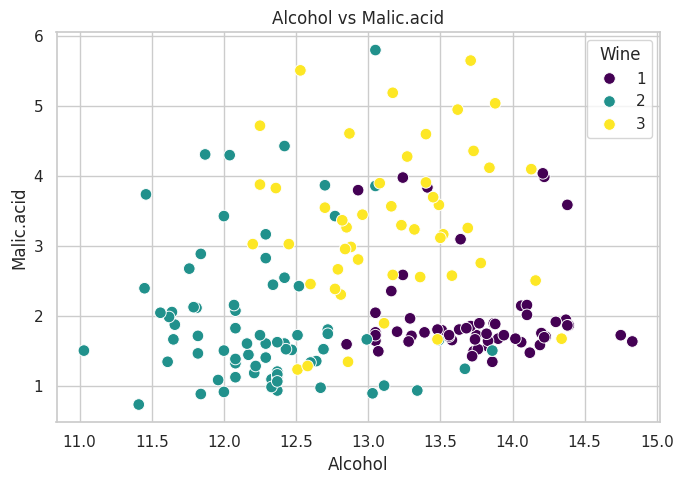

In [22]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Malic.acid',
    hue=target_col,
    palette="viridis",
    s=70
)

plt.title("Alcohol vs Malic.acid")
plt.xlabel("Alcohol")
plt.ylabel("Malic.acid")

plt.tight_layout()
plt.show()

## 17. IQR을 이용한 이상치 탐지

IQR은 3사분위수와 1사분위수의 차이입니다.

`IQR = Q3 - Q1`

일반적으로 다음 범위를 벗어나는 값을 이상치 후보로 판단합니다.

- 하한: `Q1 - 1.5 × IQR`
- 상한: `Q3 + 1.5 × IQR`

이상치로 탐지되었다고 해서 반드시 삭제해야 하는 것은 아닙니다. 실제 오류인지 정상적인 극단값인지 추가 확인이 필요합니다.

In [23]:
# 변수를 하나씩 꺼내서 이상치 개수를 센다
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)    # 1사분위수 (하위 25% 지점)
    Q3 = df[col].quantile(0.75)    # 3사분위수 (하위 75% 지점)

    IQR = Q3 - Q1                  # 중간 50% 구간의 길이

    lower = Q1 - 1.5 * IQR         # 이 값보다 작으면 이상치 후보
    upper = Q3 + 1.5 * IQR         # 이 값보다 크면 이상치 후보

    # 하한보다 작거나(|는 '또는') 상한보다 큰 행만 골라낸다
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    # f-string 서식: :22s = 22칸 문자열 자리, :2d = 2칸 정수 자리, :.2f = 소수 둘째 자리
    print(
        f"{col:22s} : "
        f"{len(outliers):2d}개 "
        f"(Lower={lower:.2f}, Upper={upper:.2f})"
    )

Alcohol                :  0개 (Lower=10.39, Upper=15.65)
Malic.acid             :  3개 (Lower=-0.62, Upper=5.30)
Ash                    :  3개 (Lower=1.69, Upper=3.08)
Acl                    :  4개 (Lower=10.75, Upper=27.95)
Mg                     :  4개 (Lower=59.50, Upper=135.50)
Phenols                :  0개 (Lower=0.16, Upper=4.39)
Flavanoids             :  0개 (Lower=-1.30, Upper=5.38)
Nonflavanoid.phenols   :  0개 (Lower=0.02, Upper=0.69)
Proanth                :  2개 (Lower=0.20, Upper=3.00)
Color.int              :  4개 (Lower=-1.25, Upper=10.67)
Hue                    :  1개 (Lower=0.28, Upper=1.63)
OD                     :  0개 (Lower=0.09, Upper=5.02)
Proline                :  0개 (Lower=-226.25, Upper=1711.75)


### 실제 이상치 데이터 확인

이상치 개수뿐 아니라 어떤 데이터가 이상치 후보인지, 그리고 **어느 품종에 속하는지** 직접 확인합니다.

In [24]:
# 품종별 이상치 개수를 나중에 표로 정리하기 위해 담아 둘 빈 리스트
outlier_summary = []

for col in numeric_cols:

    # 위 셀과 같은 방식으로 이상치 기준을 계산
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    # 이상치가 있는 변수만: 해당 변수 값과 품종을 표로 출력
    if len(outliers) > 0:
        print(f"\n[{col} 이상치]")
        display(outliers[[col, target_col]])

        # 이상치가 어느 품종에 몇 개씩 있는지 세어서 리스트에 기록
        for cls, cnt in outliers[target_col].value_counts().sort_index().items():
            outlier_summary.append({"variable": col, "Wine": cls, "count": cnt})


[Malic.acid 이상치]


,Malic.acid,Wine
123,5.80,2
137,5.51,3
173,5.65,3



[Ash 이상치]


,Ash,Wine
25,3.22,1
59,1.36,2
121,3.23,2



[Acl 이상치]


...

,Proanth,Wine
95,3.28,2
110,3.58,2



[Color.int 이상치]


,Color.int,Wine
151,10.80,3
158,13.00,3
159,11.75,3
166,10.68,3



[Hue 이상치]


,Hue,Wine
115,1.71,2


### 품종별 이상치 개수 요약

전체 데이터 기준으로 탐지한 이상치가 어느 품종에 몰려 있는지 표로 정리합니다.

In [25]:
outlier_table = (
    pd.DataFrame(outlier_summary)                                  # 기록한 리스트를 표로 변환
      .pivot(index="variable", columns="Wine", values="count")     # 행=변수, 열=품종 형태로 재배치
      .fillna(0)                                                   # 이상치가 없는 칸은 0으로
      .astype(int)                                                 # 정수로 변환
)

# 변수별 총 이상치 개수를 마지막 열에 추가
outlier_table["total"] = outlier_table.sum(axis=1)

display(outlier_table)

Wine,1,2,3,total
variable,,,,
Acl,0,4,0,4
Ash,1,2,0,3
Color.int,0,0,4,4
Hue,0,1,0,1
Malic.acid,0,1,2,3
Mg,0,4,0,4
Proanth,0,2,0,2


## 18. 품종별 평균값 비교

품종별 평균을 하나의 막대그래프로 비교합니다.
그런데 와인 데이터는 변수마다 단위와 크기가 크게 달라서 원래 값 그대로 그리면 `Proline`만 보이고 나머지는 거의 보이지 않습니다.

그래서 각 변수를 **표준화(z-score: 평균 0, 표준편차 1)** 한 뒤 품종별 평균을 비교합니다.

값이 0보다 크면 전체 평균보다 높은 품종, 작으면 낮은 품종입니다.

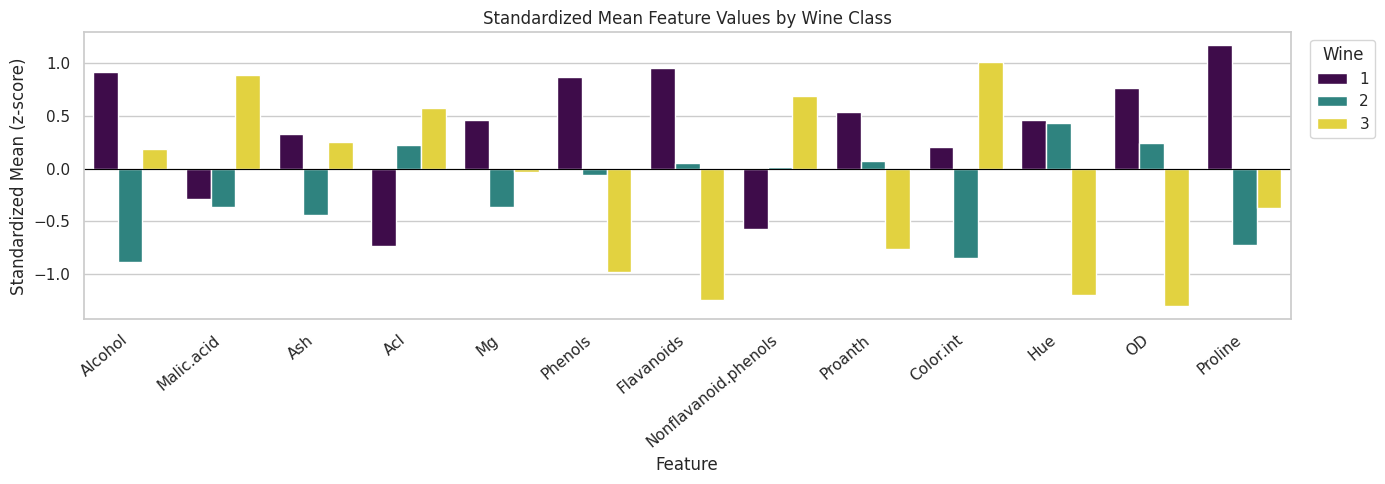

In [26]:
df_z = df.copy()   # 원본 df는 건드리지 않도록 복사본을 사용
df_z[numeric_cols] = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()

# 표준화한 값의 품종별 평균을 구하고,
mean_long = (
    df_z.groupby(target_col)[numeric_cols]
        .mean()
        .reset_index()                       # Wine을 인덱스에서 일반 열로 꺼낸다
        .melt(
            id_vars=target_col,              # 그대로 둘 열
            var_name="Feature",              # 변수 이름이 들어갈 새 열
            value_name="Standardized Mean"   # 평균 값이 들어갈 새 열
        )
)

plt.figure(figsize=(14, 5))

sns.barplot(
    data=mean_long,
    x="Feature",
    y="Standardized Mean",
    hue=target_col,
    palette="viridis"
)

plt.axhline(0, color="black", linewidth=0.8)   # 전체 평균(0) 기준선
plt.title("Standardized Mean Feature Values by Wine Class")
plt.xlabel("Feature")
plt.ylabel("Standardized Mean (z-score)")

plt.xticks(rotation=40, ha="right")            # 긴 변수 이름이 겹치지 않게 기울인다
plt.legend(title="Wine", bbox_to_anchor=(1.01, 1), loc="upper left")   # 범례를 그래프 바깥으로

plt.tight_layout()
plt.show()

## 19. 변동계수(CV) 확인

변동계수는 표준편차를 평균으로 나눈 값입니다.

`CV = 표준편차 / 평균`

단위와 크기가 서로 다른 변수들의 **상대적인 흩어짐 정도**를 비교할 때 사용합니다.
표준편차만 비교하면 값이 큰 변수(`Proline`)가 항상 커 보이는 문제가 있기 때문입니다.

변동계수(CV) 큰 순서


,CV
Flavanoids,0.492
Malic.acid,0.478
Color.int,0.458
Proline,0.422
Proanth,0.360
Nonflavanoid.phenols,0.344
Phenols,0.273
OD,0.272
Hue,0.239
Acl,0.171


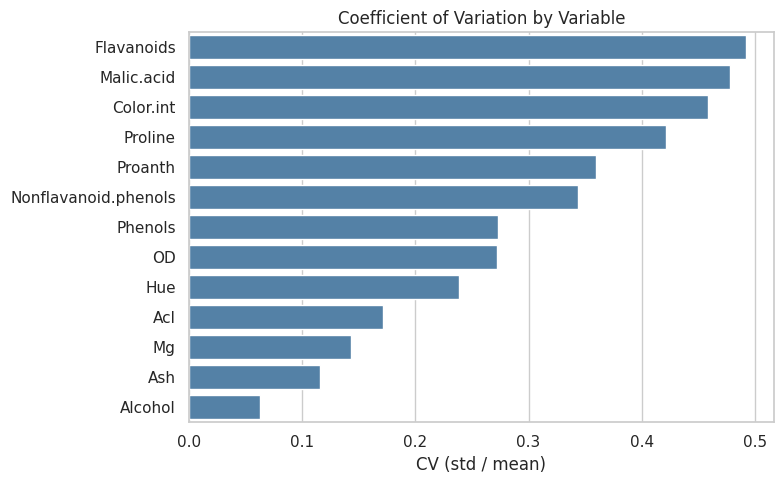

In [27]:
# 변동계수(CV) = 표준편차 / 평균
# 단위가 다른 변수끼리도 '평균 대비 얼마나 흩어져 있는지'를 비교할 수 있다
cv = (df[numeric_cols].std() / df[numeric_cols].mean()).sort_values(ascending=False)

print("변동계수(CV) 큰 순서")
display(cv.round(3).to_frame("CV"))

plt.figure(figsize=(8, 5))

sns.barplot(x=cv.values, y=cv.index, color="steelblue")

plt.title("Coefficient of Variation by Variable")
plt.xlabel("CV (std / mean)")
plt.ylabel("")

plt.tight_layout()
plt.show()

## 20. 변수별 품종 분리도 확인

어떤 변수가 품종을 가장 잘 구별하는지 수치로 비교합니다.
여기서는 일원분산분석(ANOVA)의 **F값**을 사용합니다.

`F = 품종 간 분산 / 품종 내 분산`

- F값이 큼: 품종 사이 평균 차이는 크고, 품종 안에서는 값이 모여 있음 → 품종 구별에 유용
- F값이 작음: 품종 사이에 값이 많이 겹침

,variable,F_value,p_value
0,Flavanoids,233.93,3.598586e-50
1,Proline,207.92,5.783168e-47
2,OD,189.97,1.393105e-44
3,Alcohol,135.08,3.319504e-36
4,Color.int,120.66,1.162008e-33
5,Hue,101.32,5.917662e-30
6,Phenols,93.73,2.137670e-28
7,Malic.acid,36.94,4.127229e-14
8,Acl,35.77,9.444473e-14
9,Proanth,30.27,5.125359e-12


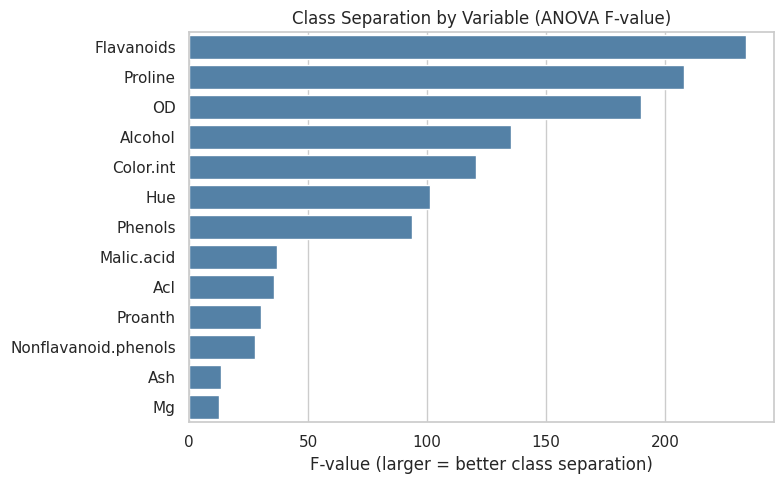

In [28]:
F_values, p_values = f_classif(df[numeric_cols], df[target_col])

separation = (
    pd.DataFrame({
        "variable": numeric_cols,
        "F_value": F_values,
        "p_value": p_values      # 아주 작을수록 '품종 간 차이가 우연이 아니다'는 뜻
    })
    .sort_values("F_value", ascending=False)
    .reset_index(drop=True)      # 정렬 후 번호를 0부터 다시 매긴다
)

display(separation.round({"F_value": 2}))

plt.figure(figsize=(8, 5))

sns.barplot(data=separation, x="F_value", y="variable", color="steelblue")

plt.title("Class Separation by Variable (ANOVA F-value)")
plt.xlabel("F-value (larger = better class separation)")
plt.ylabel("")

plt.tight_layout()
plt.show()

## 21. EDA 결과를 어떻게 해석할 것인가

이 실습에서 EDA의 흐름은 다음과 같습니다.

**데이터 구조 확인 → 데이터 품질 확인 → 레이블 확인 → 기술통계 → 분포 확인 → 품종별 비교 → 변수 관계 확인 → 상관관계 → 이상치 → 변동계수 → 중요한 변수 탐색**

### 데이터 품질과 레이블
- 데이터는 178행 x 14열(측정 변수 13개 + 품종 레이블 1개)이며, 결측치와 중복 행은 모두 0개입니다. 별도의 정제 없이 분석할 수 있는 상태입니다.
- 품종별 개수는 1번 59개(33.1%), 2번 71개(39.9%), 3번 48개(27.0%)입니다. 붓꽃(50/50/50)처럼 완전히 균형은 아니지만 한 클래스가 지나치게 적은 수준은 아니어서, 심한 클래스 불균형 문제는 아닙니다. 다만 이후 분류 실습에서 데이터를 나눌 때는 클래스 비율을 유지(`stratify`)하는 것이 좋습니다.

### 품종을 구별하는 데 유용한 변수
- ANOVA F값 기준 상위 변수는 `Flavanoids`(233.9), `Proline`(207.9), `OD`(190.0), `Alcohol`(135.1), `Color.int`(120.7) 순입니다. 반대로 `Mg`(12.4), `Ash`(13.3)는 품종 사이에 값이 많이 겹쳐 구별력이 낮습니다.
- 한 변수만으로 세 품종이 모두 갈리는 것은 아닙니다. `Proline`은 1번 품종의 평균이 1115.7로 높지만 2번(519.5)과 3번(629.9)은 서로 비슷해서 **1번만 잘 구별**합니다. `Flavanoids`는 3번 품종의 평균이 0.78로 매우 낮아 **3번을 잘 구별**합니다(1번 2.98, 2번 2.08). `Color.int`는 2번(3.09)이 낮고 3번(7.40)이 높습니다.
- 그래서 변수를 **조합**하면 구별이 잘 됩니다. `Flavanoids`와 `Color.int` 산점도에서는 세 품종이 서로 다른 위치에 모이는 반면, `Alcohol`과 `Malic.acid` 산점도에서는 품종이 많이 겹칩니다. 붓꽃에서 꽃잎 변수가 꽃받침 변수보다 구별을 잘했던 것과 같은 구조입니다.

### 변수 간 상관관계
- 상관이 가장 큰 쌍은 `Phenols`-`Flavanoids`(0.865), `Flavanoids`-`OD`(0.787), `Phenols`-`OD`(0.700)입니다. 세 변수가 비슷한 정보를 담고 있어, 모델에 모두 넣으면 중복된 정보가 들어갈 수 있습니다(다중공선성 가능성).
- `Alcohol`-`Proline`(0.644)도 비교적 높은 양의 상관을 보입니다. 붓꽃의 꽃잎 길이-너비 상관(0.963)만큼 극단적으로 높은 쌍은 없습니다.

### 이상치
- IQR 기준으로 7개 변수(`Malic.acid` 3개, `Ash` 3개, `Acl` 4개, `Mg` 4개, `Proanth` 2개, `Color.int` 4개, `Hue` 1개)에서 이상치 후보가 나왔고, 나머지 6개 변수는 0개입니다. 품종 구별력이 높았던 `Flavanoids`, `Proline`, `OD`, `Alcohol`에는 이상치가 없습니다.
- 품종별로 나눠 보면 `Acl` 4개와 `Mg` 4개는 모두 2번 품종에, `Color.int` 4개는 모두 3번 품종에 속합니다. 이는 오류라기보다 **해당 품종의 특성(전체 기준으로 보면 극단값처럼 보이는 것)**일 가능성이 있어, 근거 없이 삭제하지 않는 것이 좋습니다.

### 변동계수와 변수 크기 차이
- 변동계수는 `Flavanoids`(0.492), `Malic.acid`(0.478), `Color.int`(0.458) 순으로 크고, `Alcohol`(0.062)이 가장 작습니다. 다만 `Alcohol`은 흩어짐이 작아도 F값이 4위(135.1)라서, **흩어짐이 작다고 구별력이 낮은 것은 아닙니다.** 품종 사이 평균 차이와 품종 안의 흩어짐을 함께 봐야 합니다.
- 변수마다 크기가 매우 다릅니다. `Proline`은 평균 746.9(표준편차 314.9)인데 `Hue`는 평균 0.96 수준입니다. 그래서 값을 그대로 쓰면 `Proline` 같은 큰 변수가 결과를 지배할 수 있습니다. 거리를 기반으로 하는 모델(KNN 등)이나 선형 모델을 쓸 때는 **표준화(스케일링)가 필요할 수 있다**는 점을 EDA에서 미리 알 수 있습니다.

### EDA를 통해 만든 질문
- 어떤 변수가 분류에 가장 유용할까? → `Flavanoids`, `Proline`, `OD`, `Alcohol`, `Color.int`가 후보입니다.
- 서로 매우 강하게 상관된 변수가 있는가? → `Phenols`, `Flavanoids`, `OD`가 서로 강하게 연관되어 있습니다.
- 이상치가 모델 학습에 영향을 줄 가능성이 있는가? → 일부 변수에 있지만 품종 특성일 수 있어, 제거 전후 성능을 비교해 보아야 합니다.
- 클래스 불균형 문제가 있는가? → 59/71/48로 크지 않지만 `stratify`는 사용하는 것이 좋습니다.
- 일부 변수만으로도 품종을 충분히 구별할 수 있는가? → 두 변수 조합(`Flavanoids` + `Color.int`)만으로도 세 품종이 꽤 분리되므로, 소수의 변수로도 높은 성능이 가능한지 확인해 볼 만합니다.

즉, EDA는 이후 분석 방향을 결정하기 위한 데이터 이해 과정입니다.